# 1. 필요한 라이브러리 불러오기

데이터 분석과 머신러닝 모델 학습에 필요한 라이브러리를 불러옵니다.

- pandas : 데이터 처리
- numpy : 수치 계산
- matplotlib : 데이터 시각화
- sklearn : 머신러닝 모델 및 평가
- optuna : 하이퍼파라미터 최적화

In [ ]:
!apt-get update -qq
!apt-get install -qq fonts-nanum

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118242 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [ ]:
!fc-list | grep Nanum

/usr/share/fonts/truetype/nanum/NanumSquareRoundB.ttf: NanumSquareRound,나눔스퀘어라운드,NanumSquareRound Bold,나눔스퀘어라운드 Bold:style=Bold,Regular
/usr/share/fonts/truetype/nanum/NanumGothicCodingBold.ttf: NanumGothicCoding,나눔고딕코딩:style=Bold
/usr/share/fonts/truetype/nanum/NanumSquareRoundR.ttf: NanumSquareRound,나눔스퀘어라운드,NanumSquareRound Regular,나눔스퀘어라운드 Regular:style=Regular
/usr/share/fonts/truetype/nanum/NanumSquareB.ttf: NanumSquare,나눔스퀘어,NanumSquare Bold,나눔스퀘어 Bold:style=Bold
/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf: NanumBarunGothic,나눔바른고딕:style=Regular
/usr/share/fonts/truetype/nanum/NanumGothic.ttf: NanumGothic,나눔고딕:style=Regular
/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf: NanumGothicCoding,나눔고딕코딩:style=Regular
/usr/share/fonts/truetype/nanum/NanumBarunGothicBold.ttf: NanumBarunGothic,나눔바른고딕:style=Bold
/usr/share/fonts/truetype/nanum/NanumGothicBold.ttf: NanumGothic,나눔고딕:style=Bold
/usr/share/fonts/truetype/nanum/NanumSquareR.ttf: NanumSquare,나눔스퀘어:style=Regular
/us

In [ ]:
!pip install -q optuna

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    cross_val_score
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import optuna

np.random.seed(42)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 8.7 MB/s eta 0:00:00


# 2. 전처리 완료 데이터 불러오기


In [ ]:
df = pd.read_csv(
    'final_dataset_230101-241231.csv',
    encoding='utf-8-sig'
)

print('데이터 크기 :', df.shape)

df.head()

df.info()

print(
    df.memory_usage(deep=True).sum() / 1024**2,
    'MB'
)

데이터 크기 : (731000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731000 entries, 0 to 730999
Data columns (total 12 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   날짜      731000 non-null  object 
 1   역명      731000 non-null  object 
 2   호선      731000 non-null  object 
 3   승차인원    731000 non-null  int64  
 4   시간      731000 non-null  int64  
 5   하차인원    731000 non-null  int64  
 6   요일      731000 non-null  int64  
 7   월       731000 non-null  int64  
 8   공휴일여부   731000 non-null  int64  
 9   기온      731000 non-null  float64
 10  강수량     731000 non-null  float64
 11  적설      731000 non-null  float64
dtypes: float64(3), int64(6), object(3)
memory usage: 66.9+ MB
193.91545486450195 MB


# 3. 데이터 기본 정보 확인

데이터의:
- 컬럼 정보
- 데이터 타입
- 결측치 여부

In [ ]:
df.info()

print()

print('결측치 개수')

print(df.isnull().sum())

print()

print('중복 데이터 개수 :')

print(df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731000 entries, 0 to 730999
Data columns (total 12 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   날짜      731000 non-null  object 
 1   역명      731000 non-null  object 
 2   호선      731000 non-null  object 
 3   승차인원    731000 non-null  int64  
 4   시간      731000 non-null  int64  
 5   하차인원    731000 non-null  int64  
 6   요일      731000 non-null  int64  
 7   월       731000 non-null  int64  
 8   공휴일여부   731000 non-null  int64  
 9   기온      731000 non-null  float64
 10  강수량     731000 non-null  float64
 11  적설      731000 non-null  float64
dtypes: float64(3), int64(6), object(3)
memory usage: 66.9+ MB

결측치 개수
날짜       0
역명       0
호선       0
승차인원     0
시간       0
하차인원     0
요일       0
월        0
공휴일여부    0
기온       0
강수량      0
적설       0
dtype: int64

중복 데이터 개수 :
0


# 4. Feature / Target 분리

머신러닝 입력 데이터(X)와 예측 대상(y)을 분리

- X : 모델이 학습에 사용할 feature
- y : 모델이 예측할 target

In [ ]:
X = df[['역명', '시간', '요일', '월',
        '공휴일여부', '기온', '강수량', '적설']]

y = df['하차인원']

print(X.shape)

print(y.shape)

(731000, 8)
(731000,)


# 5. One-Hot Encoding

문자형 데이터(역명)를 숫자 형태로 변환합니다.

RandomForest 모델은 문자열을 직접 학습할 수 없기 때문에
One-Hot Encoding을 사용합니다.

In [ ]:
X_encoded = pd.get_dummies(
    X,
    columns=['역명']
)

print(X_encoded.shape)

X_encoded.head()

(731000, 57)


,시간,요일,월,공휴일여부,기온,강수량,적설,역명_강남,역명_강변(동서울터미널),역명_건대입구,...,역명_을지로입구,역명_이대,역명_잠실(송파구청),역명_잠실나루,역명_잠실새내,역명_종합운동장,역명_충정로(경기대입구),역명_한양대,역명_합정,역명_홍대입구
0,5,6,1,1,0.8,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,5,6,1,1,0.8,0.0,0.0,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,5,6,1,1,0.8,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,5,6,1,1,0.8,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,6,1,1,0.8,0.0,0.0,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
print('X 결측치 개수 :')

print(X_encoded.isnull().sum().sum())

print()

print('y 결측치 개수 :')

print(y.isnull().sum())

print()

print('X shape :')

print(X_encoded.shape)

print()

print('y shape :')

print(y.shape)

X 결측치 개수 :
0

y 결측치 개수 :
0

X shape :
(731000, 57)

y shape :
(731000,)


In [ ]:
print(df.shape)

print(df.isnull().sum()[df.isnull().sum() > 0])

(731000, 12)
Series([], dtype: int64)


# 6. 학습용 / 테스트용 데이터 분리

데이터를:
- 학습용 데이터
- 테스트용 데이터

로 분리

- 학습 데이터 : 모델 학습에 사용
- 테스트 데이터 : 최종 성능 평가에 사용

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print('X_train shape :', X_train.shape)

print('X_test shape :', X_test.shape)

print()

print('y_train shape :', y_train.shape)

print('y_test shape :', y_test.shape)

print()

print(
    'Train 비율 :',
    len(X_train) / len(X_encoded)
)

print(
    'Test 비율 :',
    len(X_test) / len(X_encoded)
)

X_train shape : (584800, 57)
X_test shape : (146200, 57)

y_train shape : (584800,)
y_test shape : (146200,)

Train 비율 : 0.8
Test 비율 : 0.2


# 7. Optuna를 이용한 하이퍼파라미터 최적화

Cross Validation을 사용하여:
- X_train 내부에서만 성능 평가
- 테스트 데이터 정보 누출 방지
- 모델 신뢰성 향상

In [ ]:
def objective(trial):

    n_estimators = trial.suggest_int(
        'n_estimators',
        50,
        100
    )

    max_depth = trial.suggest_int(
        'max_depth',
        25,
        30
    )

    min_samples_split = trial.suggest_int(
        'min_samples_split',
        2,
        10
    )

    min_samples_leaf = trial.suggest_int(
        'min_samples_leaf',
        1,
        5
    )

    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )

    score = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring='r2'
    ).mean()

    return score


study = optuna.create_study(
    direction='maximize'
)

study.optimize(
    objective,
    n_trials=15
)

[I 2026-06-01 07:38:09,530] A new study created in memory with name: no-name-d25a6076-c8cc-4586-b311-c5190095ae90
[I 2026-06-01 07:39:40,691] Trial 0 finished with value: 0.9479772655358462 and parameters: {'n_estimators': 55, 'max_depth': 25, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 0 with value: 0.9479772655358462.
[I 2026-06-01 07:41:44,568] Trial 1 finished with value: 0.9514409891443053 and parameters: {'n_estimators': 73, 'max_depth': 26, 'min_samples_split': 2, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.9514409891443053.
[I 2026-06-01 07:43:40,670] Trial 2 finished with value: 0.9514102608932505 and parameters: {'n_estimators': 71, 'max_depth': 26, 'min_samples_split': 8, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.9514409891443053.
[I 2026-06-01 07:45:11,374] Trial 3 finished with value: 0.957863002213057 and parameters: {'n_estimators': 52, 'max_depth': 28, 'min_samples_split': 6, 'min_samples_leaf': 3}. Best is trial 3 with value: 0.9

# 8. 최적의 하이퍼파라미터로 최종 모델 생성

Optuna가 찾은 최적의 하이퍼파라미터를 사용하여
최종 RandomForest 모델을 생성

In [ ]:
best_params = study.best_params

print('Best Parameters :')

print(best_params)

print()

print('Best CV Score :')

print(study.best_value)

model = RandomForestRegressor(
    **best_params,
    random_state=42,
    n_jobs=-1
)

Best Parameters :
{'n_estimators': 100, 'max_depth': 30, 'min_samples_split': 10, 'min_samples_leaf': 2}

Best CV Score :
0.9630711399280298


# 9. 모델 학습

최종 RandomForest 모델을 학습

In [ ]:
import time

start = time.time()

model.fit(
    X_train,
    y_train
)

end = time.time()

print('모델 학습 완료')

print()

print(
    '학습 시간 :',
    round(end - start, 2),
    '초'
)

모델 학습 완료

학습 시간 : 103.01 초


# 10. 예측 수행

테스트 데이터를 이용하여 예측

In [ ]:
# 이 셀은 모델만 불러와서 예측해보기 위한 코드이므로 학습까지 포함해서 순서대로 실행시에는 실행시키지 말 것
import joblib

# 모델 불러오기
model = joblib.load(
    'randomforest_dropoff_model.pkl'
)

print("모델 로드 완료")

모델 로드 완료


In [ ]:
y_pred = model.predict(X_test)

print('예측 완료')

print()

print(y_pred[:5])

print()

result_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10]
})

print(result_df)

예측 완료

[ 123.68071174 4001.00891252  856.3143849   277.72240331  577.14550946]

   Actual    Predicted
0     111   123.680712
1    3547  4001.008913
2     342   856.314385
3     313   277.722403
4     467   577.145509
5     827   863.380337
6     499   786.272993
7     840   856.314385
8     188   218.121028
9     140   129.689607


# 11. 모델 성능 평가

- MAE : 평균 오차 크기
- RMSE : 큰 오차까지 고려한 평균 오차
- R² Score : 모델 설명력

In [ ]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = mse ** 0.5

r2 = r2_score(
    y_test,
    y_pred
)

print('모델 성능 평가')

print()

print(f"MAE: {mae:.2f}")

print(f"MSE: {mse:.2f}")

print(f"RMSE: {rmse:.2f}")

print(f"R2 Score: {r2:.4f}")

모델 성능 평가

MAE: 189.44
MSE: 116092.63
RMSE: 340.72
R2 Score: 0.9631


# 12. 실제값과 예측값 시각화

실제 값과 모델의 예측값을 비교하여
예측 성능을 시각적으로 확인

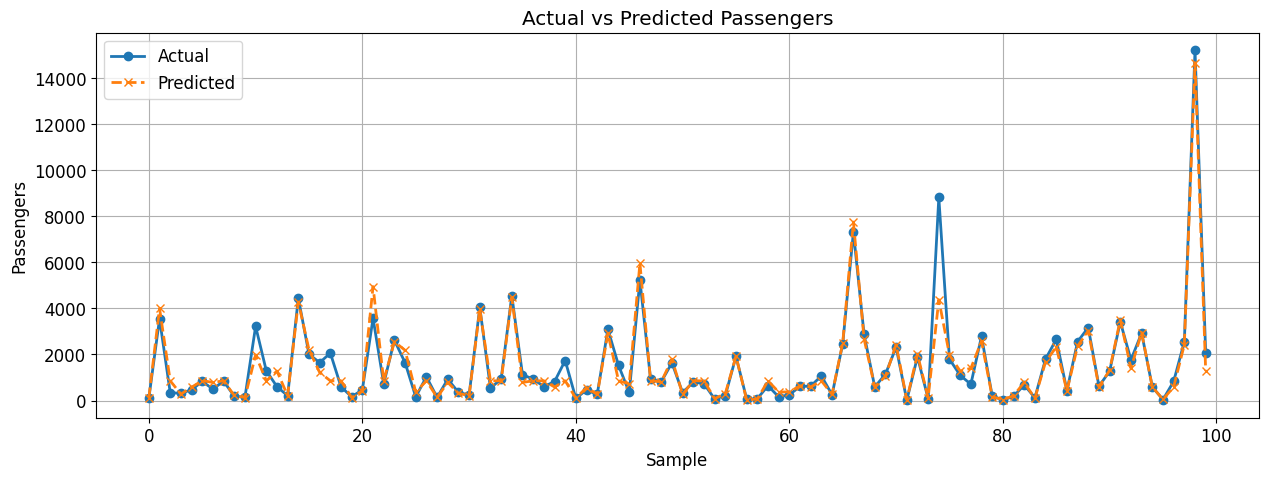

In [ ]:
plt.figure(figsize=(15,5))

sample_size = 100

actual = y_test[:sample_size].values
predicted = y_pred[:sample_size]

plt.plot(
    actual,
    marker='o',
    linewidth=2,
    label='Actual'
)

plt.plot(
    predicted,
    linestyle='--',
    marker='x',
    linewidth=2,
    label='Predicted'
)

plt.title('Actual vs Predicted Passengers')

plt.xlabel('Sample')

plt.ylabel('Passengers')

plt.legend()

plt.grid()

plt.show()

# 13. 산점도를 이용한 예측 성능 시각화

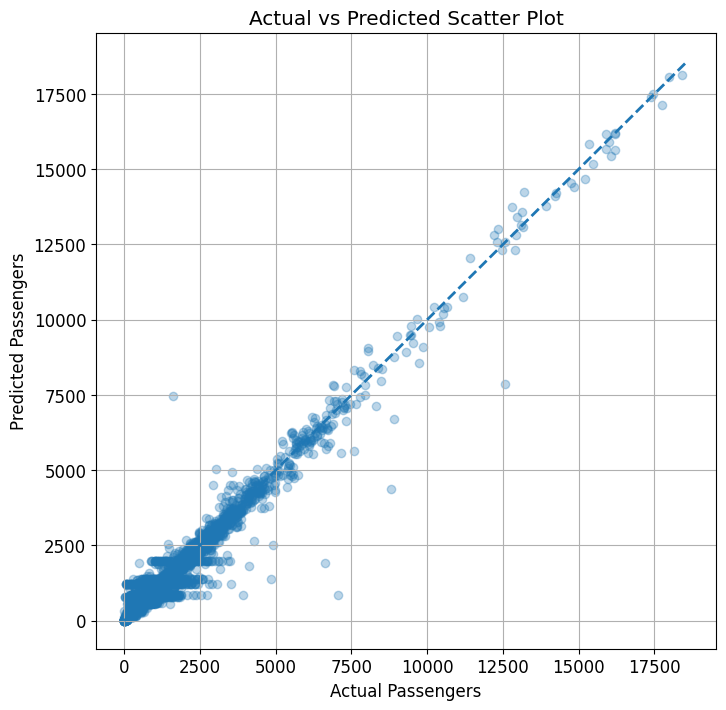

In [ ]:
sample_size = 5000

plt.figure(figsize=(8,8))

plt.scatter(
    y_test[:sample_size],
    y_pred[:sample_size],
    alpha=0.3
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--',
    linewidth=2
)

plt.xlabel('Actual Passengers')

plt.ylabel('Predicted Passengers')

plt.title('Actual vs Predicted Scatter Plot')

plt.grid()

plt.show()

# 14. Feature Importance 분석

RandomForest 모델이 어떤 feature를 중요하게 사용했는지 분석

Feature Importance를 통해:
- 어떤 요소가 예측에 큰 영향을 주는지
- 모델이 어떤 패턴을 중요하게 판단했는지

확인할 수 있습니다.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

font_prop = fm.FontProperties(fname=font_path)

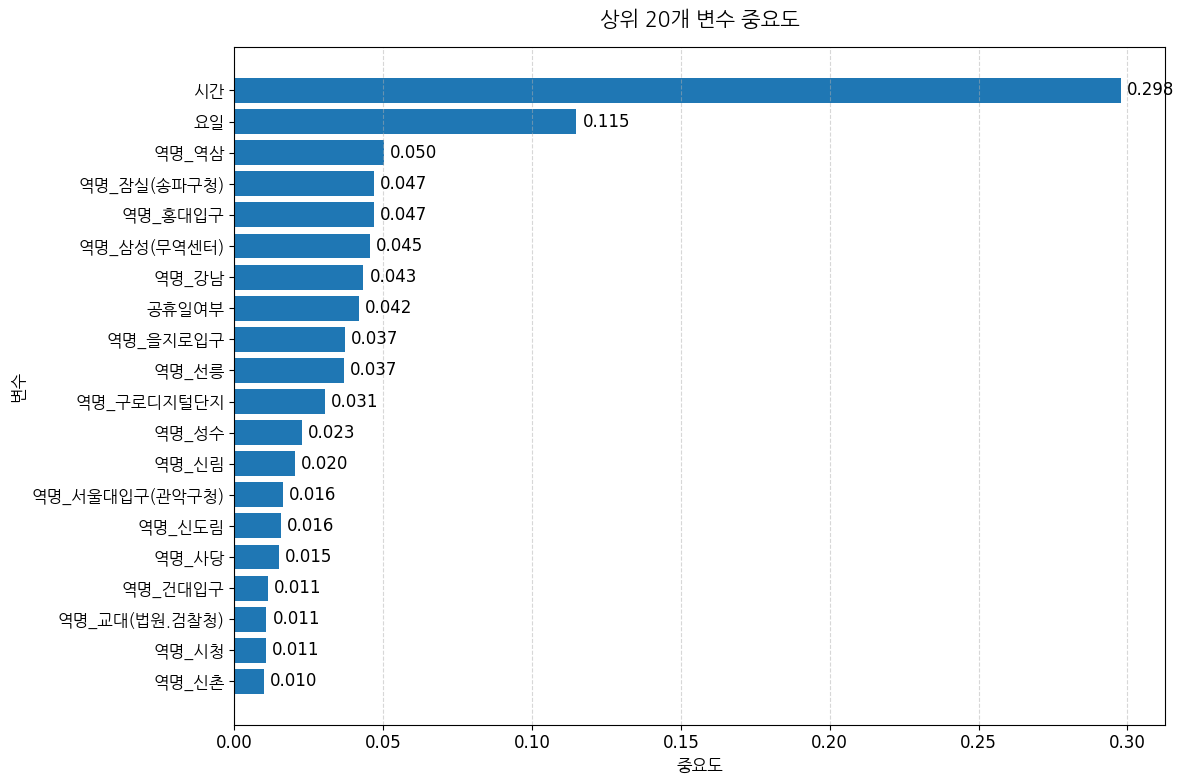

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

font_prop = fm.FontProperties(fname=font_path)

# Calculate feature importances
importance = model.feature_importances_

# Create a DataFrame for feature importances
importance_df = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': importance
})

# Sort by importance in descending order and get the top 20
top20 = importance_df.sort_values(
    by='importance',
    ascending=False
).head(20)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    top20['feature'],
    top20['importance']
)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.002,
        bar.get_y() + bar.get_height()/2,
        f'{width:.3f}',
        va='center'
    )

plt.title(
    '상위 20개 변수 중요도',
    fontproperties=font_prop,
    fontsize=15,
    pad=15
)

plt.xlabel(
    '중요도',
    fontproperties=font_prop
)

plt.ylabel(
    '변수',
    fontproperties=font_prop
)

# y축 항목에도 폰트 적용
for label in plt.gca().get_yticklabels():
    label.set_fontproperties(font_prop)

plt.gca().invert_yaxis()

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()

plt.show()

# 15. 모델 저장

In [ ]:
import joblib

# 모델 저장
joblib.dump(
    model,
    'randomforest_dropoff_model.pkl'
)

# 컬럼 저장
joblib.dump(
    X_encoded.columns,
    'model_columns.pkl'
)

# 최적 파라미터 저장
joblib.dump(
    best_params,
    'best_params.pkl'
)

# Feature Importance 저장
importance_df.to_csv(
    'feature_importance.csv',
    index=False
)

print('모델 및 관련 파일 저장 완료')

모델 및 관련 파일 저장 완료


Streamit에서 불러오는 코드

In [ ]:
import joblib

# 모델 불러오기
model = joblib.load(
    'randomforest_dropoff_model.pkl'
)

# 컬럼 불러오기
model_columns = joblib.load(
    'model_columns.pkl'
)

print('모델 및 컬럼 불러오기 완료')

모델 및 컬럼 불러오기 완료


# 16. 예측 오차 TOP10 분석

- 예측 오차가 가장 큰 데이터 TOP10 추출
- 실제값과 예측값 비교
- 오차가 발생한 날짜 및 역 확인

을 통해 모델이 어떤 상황에서 예측에 실패하는지 분석

In [ ]:
# 원본 데이터 기준으로 다시 분할

X_original = df[['날짜', '역명', '시간', '요일', '월',
                 '공휴일여부', '기온', '강수량', '적설']]

X_train_org, X_test_org, _, _ = train_test_split(
    X_original,
    y,
    test_size=0.2,
    random_state=42
)

# 오차 계산
errors = abs(y_test.values - y_pred)

# 오차 TOP10
top10_idx = np.argsort(errors)[-10:]

print("=" * 100)
print("오차 TOP10 상세 정보")
print("=" * 100)

for rank, idx in enumerate(reversed(top10_idx), start=1):

    print(f"\n순위 : {rank}")
    print(f"날짜 : {X_test_org.iloc[idx]['날짜']}")
    print(f"역명 : {X_test_org.iloc[idx]['역명']}")
    print(f"시간 : {X_test_org.iloc[idx]['시간']}")
    print(f"요일 : {X_test_org.iloc[idx]['요일']}")
    print(f"월 : {X_test_org.iloc[idx]['월']}")

    print(f"실제값 : {y_test.values[idx]:.0f}")
    print(f"예측값 : {y_pred[idx]:.0f}")
    print(f"오차 : {errors[idx]:.0f}")

    print("-" * 50)

오차 TOP10 상세 정보

순위 : 1
날짜 : 2023-05-01
역명 : 삼성(무역센터)
시간 : 8
요일 : 0
월 : 5
실제값 : 2136
예측값 : 15745
오차 : 13609
--------------------------------------------------

순위 : 2
날짜 : 2023-06-18
역명 : 종합운동장
시간 : 18
요일 : 6
월 : 6
실제값 : 13983
예측값 : 562
오차 : 13421
--------------------------------------------------

순위 : 3
날짜 : 2024-05-01
역명 : 성수
시간 : 8
요일 : 2
월 : 5
실제값 : 1429
예측값 : 12217
오차 : 10788
--------------------------------------------------

순위 : 4
날짜 : 2023-06-17
역명 : 종합운동장
시간 : 16
요일 : 5
월 : 6
실제값 : 10520
예측값 : 856
오차 : 9664
--------------------------------------------------

순위 : 5
날짜 : 2024-05-01
역명 : 시청
시간 : 8
요일 : 2
월 : 5
실제값 : 1692
예측값 : 10701
오차 : 9009
--------------------------------------------------

순위 : 6
날짜 : 2023-05-01
역명 : 시청
시간 : 8
요일 : 0
월 : 5
실제값 : 1523
예측값 : 10253
오차 : 8730
--------------------------------------------------

순위 : 7
날짜 : 2023-05-13
역명 : 종합운동장
시간 : 18
요일 : 5
월 : 5
실제값 : 8854
예측값 : 1112
오차 : 7742
--------------------------------------------------

순위 : 8
날짜 : 20

# 17. 특이 사례 분석 - 업무지구 역

오차 TOP10 분석 결과,
삼성(무역센터), 시청, 성수역에서
매우 큰 과대예측이 발생

특히 2023-05-01과 2024-05-01에
동일한 패턴이 반복적으로 확인

이는 근로자의 날로 인해
업무지구의 출근 수요가 급감하였으나,
모델에는 관련 정보가 반영되지 않았기 때문으로 추정

In [ ]:
df[
    (df['역명'] == '삼성(무역센터)') &
    (df['시간'] == 8)
][['날짜','하차인원']].sort_values(
    by='하차인원',
    ascending=False
).head(20)

,날짜,하차인원
117568,2023-06-08,17423
118968,2023-07-06,17025
137418,2024-07-09,17002
117218,2023-06-01,16983
124118,2023-10-17,16923
123468,2023-10-04,16915
111218,2023-02-01,16899
115768,2023-05-03,16893
113718,2023-03-23,16732
122468,2023-09-14,16728


In [ ]:
target = df[
    (df['날짜'] == '2023-05-01') &
    (df['역명'] == '삼성(무역센터)') &
    (df['시간'] == 8)
]

print(target.T)

           115668
날짜     2023-05-01
역명       삼성(무역센터)
호선            2호선
승차인원          424
시간              8
하차인원         2136
요일              0
월               5
공휴일여부           0
기온           11.2
강수량           0.0
적설            0.0


In [ ]:
df[
    (
        (df['날짜'] == '2023-05-01') |
        (df['날짜'] == '2024-05-01')
    ) &
    (df['역명'] == '시청') &
    (df['시간'] == 8)
][['날짜','역명','하차인원','공휴일여부']]

,날짜,역명,하차인원,공휴일여부
115650,2023-05-01,시청,1523,0
133950,2024-05-01,시청,1692,0


# 18. 특이 사례 분석 - 종합운동장역

오차 TOP10 중 다수의 사례가 종합운동장역에서 발생

이는 프로야구 경기,
콘서트,
대규모 행사 등의 외부 요인이
현재 모델에 반영되지 않았기 때문으로 판단

In [ ]:
df[
    (df['역명'] == '종합운동장') &
    (
        df['날짜'].isin([
            '2023-05-13',
            '2023-06-17',
            '2023-06-18',
            '2023-06-25',
            '2023-06-30',
            '2024-04-14'
        ])
    )
][['날짜','시간','하차인원']]

,날짜,시간,하차인원
6617,2023-05-13,5,33
8367,2023-06-17,5,41
8417,2023-06-18,5,41
8767,2023-06-25,5,34
9017,2023-06-30,5,35
...,...,...,...
702767,2023-06-17,0,129
702817,2023-06-18,0,10
703167,2023-06-25,0,41
703417,2023-06-30,0,93


# 19. 오차 원인 분석 및 개선 방향

1. 업무지구 역
   - 삼성(무역센터)
   - 시청
   - 성수

   근로자의 날에 출근 수요가 급감

2. 종합운동장역
   - 경기
   - 콘서트
   - 행사

   외부 이벤트 영향

3. 현재 모델 한계
   - 행사 일정 정보 없음
   - 근로자의 날 정보 없음

4. 개선 방향
   - 근로자의 날 변수 추가
   - 행사 일정 변수 추가
   - 경기 일정 변수 추가